In [18]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from ISLP.models import (ModelSpec as MS, summarize,poly)
import matplotlib.pyplot as plt
from statsmodels.stats.anova import anova_lm
import math

rng = np.random.default_rng(10)
x1 = rng.uniform(0, 1, size=100)
x2 = 0.5 * x1 + rng.normal(size=100) / 10
y = 2 + 2 * x1 + 0.3 * x2 + rng.normal(size=100)

b0 = 2
b1 = 2
b2 = 0.3

Между x1 и х2 прямая корреляция.

Text(0, 0.5, 'x2')

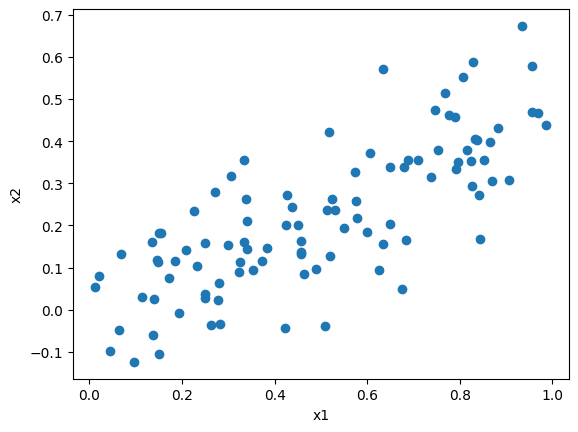

In [19]:
ax = plt.subplots()[1]
ax.scatter(x1, x2)
ax.set_xlabel('x1')
ax.set_ylabel('x2')

In [20]:
data = pd.DataFrame({'x1': x1, 'x2': x2, 'intercept': 1})

results = sm.OLS(y, data).fit()
summarize(results)

,coef,std err,t,P>|t|
x1,1.6154,0.527,3.065,0.003
x2,0.9428,0.831,1.134,0.259
intercept,1.9579,0.190,10.319,0.000


Оригинал - b0 = 2 b1 = 2 b2 = 0.3

Неповторимая копия - b0 = 1.9579 b1 = 1.6154 b2 = 0.9428

Нулевые гипотезы для в1 = 0 или в2 = 0 мы можем отклонить. Хотя значения Т и Р для х2 конечно намекают что что-то с этим показателем не так

In [21]:
data1 = pd.DataFrame({'x1': x1, 'intercept': 1})

results1 = sm.OLS(y, data1).fit()
summarize(results1)

,coef,std err,t,P>|t|
x1,2.0771,0.335,6.196,0.0
intercept,1.9371,0.189,10.242,0.0


Результаты близки к правдивым, нудевую гипотезу по в1 = 0 можно отклонить.

In [22]:
data2 = pd.DataFrame({'x2': x2, 'intercept': 1})

results2 = sm.OLS(y, data2).fit()
summarize(results2)

,coef,std err,t,P>|t|
x2,2.9103,0.550,5.291,0.0
intercept,2.3239,0.154,15.124,0.0


Интересный результат, поскольку полученный коээфициент В1 сильно выше реального, нр он явно учитывает кореляцию с х1. Нулевую гипотезу для в1 = 0 отклонить можно

В моем понимании результаты тут не противоречащие, а намекающие на коллинеарность между х1 и х2, хотя это я такой просто сразу
про такую зависимость знаю)


In [23]:
x1 = np.concatenate([x1, [0.1]])
x2 = np.concatenate([x2, [0.8]])
y = np.concatenate([y, [6]])

data3 = pd.DataFrame({'x1': x1, 'x2': x2, 'intercept': 1})

results3 = sm.OLS(y, data3).fit()
summarize(results3)

,coef,std err,t,P>|t|
x1,0.8575,0.466,1.838,0.069
x2,2.2663,0.705,3.216,0.002
intercept,2.0618,0.192,10.720,0.000


Интересно, поскольку из-за одного значения у нас очень сильно поменяли соээфициенты, то есть можно предположить, что оно
выбивается из общего ряда и является аутлаером.


Text(0, 0.5, 'x2')

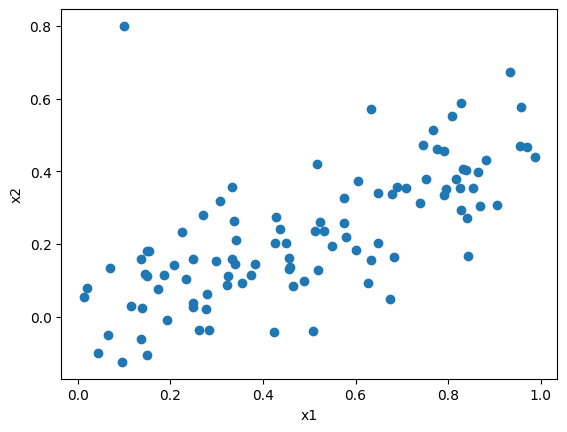

In [24]:
ax = plt.subplots()[1]
ax.scatter(x1, x2)
ax.set_xlabel('x1')
ax.set_ylabel('x2')

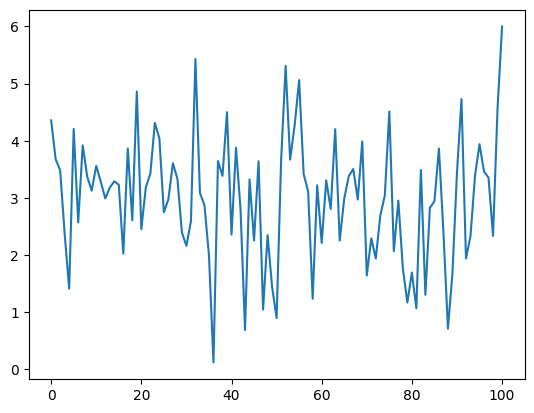

In [28]:
ax = plt.subplots()[1]
ax.plot(y)

Получается что по значению это не аутлаер, но есть весомая разбалансировка? 